In [1]:
import h5py
import numpy as np

data_dir = "../data/test"
files = ["check1.h5", "test2.h5"]

flux_sums = {}
for fname in files:
    with h5py.File(f"{data_dir}/{fname}", "r") as f:
        clean_cube = f["clean_cube"][:]
        flux_sums[fname] = np.sum(clean_cube)
        print(f"{fname}: clean_cube shape={clean_cube.shape}, total flux={flux_sums[fname]:.6e}")

total_flux = sum(flux_sums.values())
print(f"\nCombined total flux (check1 + test2): {total_flux:.6e}")


check1.h5: clean_cube shape=(60, 96, 96), total flux=3.241393e+02
test2.h5: clean_cube shape=(60, 96, 96), total flux=2.161239e+01

Combined total flux (check1 + test2): 3.457517e+02


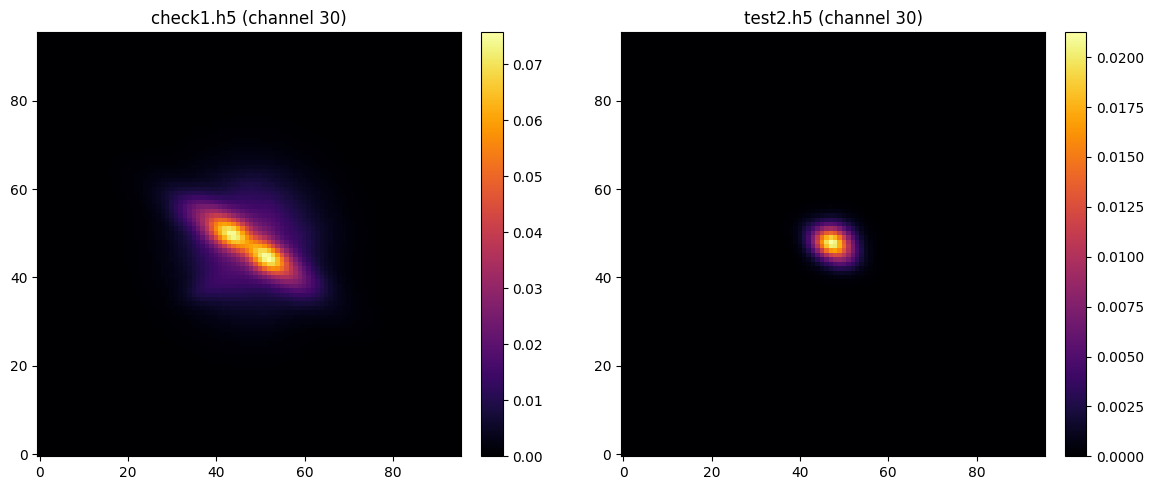

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(files), figsize=(6 * len(files), 5))

for ax, fname in zip(axes, files):
    with h5py.File(f"{data_dir}/{fname}", "r") as f:
        clean_cube = f["clean_cube"][:]
        central_channel = clean_cube.shape[0] // 2
        im = ax.imshow(clean_cube[central_channel], origin="lower", cmap="inferno")
        ax.set_title(f"{fname} (channel {central_channel})")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
